In [210]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
import operator

from langchain_huggingface import HuggingFaceEndpoint
from langchain_huggingface.chat_models import ChatHuggingFace
from dotenv import load_dotenv
import os

In [211]:
load_dotenv()

# Initialize HuggingFace LLM
# Initialize Groq LLM
# Initialize HuggingFace LLM
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_KEY"),
    temperature=0.1,
    max_new_tokens=512,
)

generator_model = ChatHuggingFace(llm=llm)
evaluation_model = ChatHuggingFace(llm=llm)
optimization_model = ChatHuggingFace(llm=llm)

In [222]:
generator_model.invoke("Tell me about Bangladeshi Briyani")

AIMessage(content=' Bangladeshi Biryani is a popular and beloved dish in Bangladeshi and Indian cuisine. It is a fragrant and flavorful rice dish that is cooked with marinated meat, vegetables, and an array of aromatic spices. The name "Biryani" comes from the Persian word "birian," which means "fried before cooking."\n\nThe preparation of Bangladeshi Biryani involves marinating the meat (usually chicken, goat, or lamb) in a mixture of yogurt, garam masala, turmeric, and other spices for several hours. The rice is also cooked separately with ghee, onions, and spices, creating a rich and flavorful base.\n\nOnce the meat and rice have been prepared, they are layered in a large pot or casserole dish. The meat is placed at the bottom, followed by a layer of rice, and then the process is repeated until all the meat and rice have been used. The dish is then sealed and cooked on low heat for an extended period of time, allowing the flavors to meld together.\n\nBangladeshi Biryani is often ser

In [212]:
# Define structured output schema for evaluation
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [213]:
# Create a structured model with the defined schema
structured_evaluator_model = evaluation_model.with_structured_output(
    TweetEvaluation,
    method="json_schema"
)

In [214]:
from langchain_core.runnables import RunnableLambda

# Add instruction to prompt
preprocess = RunnableLambda(lambda prompt: prompt + "\n\nReturn your answer in JSON format.")

# Chain with first model
safe_model_1 = preprocess | structured_evaluator_model

In [215]:
# Define state structure
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration : int
    max_iterations: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [216]:
# Helper to deeply unpack tuple/list to get message object or string
def unpack_response(response):
    # Unpack until not tuple/list
    while isinstance(response, (tuple, list)) and len(response) > 0:
        response = response[0]
    return response

# Define tweet generation function
def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a creative social media content creator."),
        HumanMessage(content=f"""
                     Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
                     
                     Rules:
                     - Do not use hashtags.
                     - Do NOT use question-asnwer format.
                     - Max 280 characters.
                     - Use observational humor, irony, sarcasm, or cultural references.
                     - Make sure the tweet is unique and has not been posted before.
                     - Think in mem logic, punchlines, or relatable scenarios.
                     - Use simple, day to day english
                     - This version {state['iteration'] +1}.
                    """)
    ]
    response = generator_model.invoke(messages)
    response = unpack_response(response)
    # Extract content if message object
    if hasattr(response, 'content'):
        response = response.content
    return {"tweet": str(response)}

# Define tweet evaluation function
def evaluate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format. Always respond in valid JSON format."),
        HumanMessage(content=f"""
    Evaluate the following tweet and respond ONLY in JSON format with the following structure:
    {{"evaluation": "approved" or "needs_improvement", "feedback": "your feedback here"}}

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Don't end with generic, throwaway, or deflating lines that weaken the humor

    Return ONLY valid JSON with "evaluation" and "feedback" fields.
    """)
    ]
    response = structured_evaluator_model.invoke(messages)
    response = unpack_response(response)

    # If response is a string, parse it as JSON
    if isinstance(response, str):
        import json
        try:
            response = json.loads(response)
            response = TweetEvaluation(**response)
        except:
            response = TweetEvaluation(evaluation="needs_improvement", feedback=response)
    elif isinstance(response, dict):
        try:
            response = TweetEvaluation(**response)
        except Exception as e:
            print(f"DEBUG: Failed to convert dict to TweetEvaluation: {e}")
            response = TweetEvaluation(evaluation="needs_improvement", feedback=str(response))
            
    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

# Define tweet optimization function
def optimize_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = optimization_model.invoke(messages)
    response = unpack_response(response)
    # Extract content if message object
    if hasattr(response, 'content'):
        response = response.content
    iteration = state['iteration'] + 1
    return {'tweet': str(response), 'iteration': iteration, 'tweet_history': [str(response)]}


In [217]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

In [218]:
# Define graph

graph = StateGraph(TweetState)

# Define nodes
graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

# Define edges
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'} )
graph.add_edge('optimize', 'evaluate')

# Compile the workflow
workflow = graph.compile()

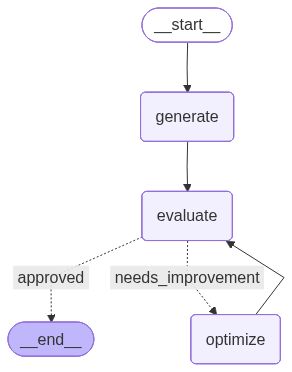

In [219]:
workflow

In [220]:

# Invoke the workflow
initial_state = {
    "topic": "Bangaladeshi Briyani",
    "iteration": 1,
    "max_iterations": 5
}
result = workflow.invoke(initial_state)

result

{'topic': 'Bangaladeshi Briyani',
 'tweet': ' "Solved a Rubik\'s cube after devouring authentic Bangaldeshi Briyani. Rice-eating skills at an all-time high! 🇧🇩 #BangaldeshiMagic #FoodieGoals #BriyaniLife"',
 'evaluation': 'approved',
 'feedback': "The tweet is original as it connects the experience of solving a Rubik's cube with eating Bangaldeshi Briyani. The use of hashtags adds to its virality potential. The tweet is punchy and under 280 characters. The format is well-formed and does not follow a setup-punchline joke structure.",
 'iteration': 2,
 'max_iterations': 5,
 'tweet_history': [' "Solved a Rubik\'s cube after devouring authentic Bangaldeshi Briyani. Rice-eating skills at an all-time high! 🇧🇩 #BangaldeshiMagic #FoodieGoals #BriyaniLife"'],
 'feedback_history': ['The tweet is long-winded and lacks originality. Consider shortening it and focusing on a clear, humorous message. Also, avoid excessive use of hashtags as it can clutter the tweet and decrease its readability.',
  "T